# Example- Modeling, simulation and control of aircraft

#### Import International Standard Atmosphere (ISA) model

In [15]:
from pyaat.atmosphere import atmosISA
atm = atmosISA()

Atmosphere class implements a series of models to provide air density $\rho$, air pressure and air temperature as a function of altitude and temperature at sea level. If no information about seal level temperature is provided 15⁰C is considered.

#### Import Newton gravity model

In [16]:
from pyaat.gravity import NewtonGravity
grav = NewtonGravity()

gravity class provides the matrix form of the vector of the gravitational field. It can be deppendend of the altitude, latitude and longitude, varying with the complexity of the adopted model. Newton's gravity is only function of the altitude.

#### Import Aircraft

In [17]:
from pyaat.aircraft import Aircraft
airc = Aircraft()

aircraft class contains all relevant information about aerodynamics, geometry and inertia of the aircraft. It also contains embeeded methods to compute the resultand aerodynamic forces and aerodynamic moments acting over the body.

#### Import propulsion

In [18]:
from pyaat.propulsion import SimpleModel
prop = SimpleModel()

Propulsion system are the only system capable to mechanical energy on the system. A propulsion system cam be composed by several heterogeneous engines, pointing at diferent directions. In this case we use a simple turbo-fan model aligned with the body.

### Build the system

In [21]:
from pyaat.system import system
System = system(atmosphere = atm, propulsion = prop, aircraft = airc, gravity = grav)

We now have a system containing atmosphere, gravity, aircraft and a propulsive system. Let's proceed to flight mechanics analysis.

# Trimmer

Trimmer is an embeeded method of system class. We can chose between the pre-designed conditions or create new trimmed conditions.

### Trimmer at cruize condition

In [22]:
Xe, Ue = System.trimmer(condition='cruize', HE =5000., VE= 150)

At cruize condition we only shall specify the desired altitude and velocity

In [28]:
from pyaat.tools import printInfo

Let's print the states at trimmed condition.

In [29]:
printInfo(Xe,Ue, frame ='aero')

--------------------------------
------------ STATES ------------
------------- AERO -------------
--------------------------------
V
150.0
-------------
alpha
1.7209607409123193
-------------
beta
1.2665996248389849e-20
-------------
phi
0.0
-------------
theta
1.7209607409126377
-------------
psi
0.0
-------------
p
-1.2463294526758558e-20
-------------
q
1.0651917044203038e-12
-------------
r
3.634252428035239e-21
-------------
x0
0.0
-------------
y0
0.0
-------------
H
5000.0


Note that the states are expressed on aerodynamic frame. To print the information on body frame we shall specify `frame ='body'`

Printing controls at trimmed condition

In [35]:
printInfo(Xe,Ue, frame='controls')

--------------------------------
----------- CONTROLS -----------
--------------------------------
delta_p
59.495488449750546
-------------
delta_e
-20.256545753428522
-------------
delta_a
-3.0697822454158513e-06
-------------
delta_r
3.193714597924145e-06


Other trimmed conditions include climb, Pull-Up maneuver and turn maneuver. For trimming using this conditions we must provide aditional information, as follows:

### Trimmer at climb condition
We shall provide the climb rate `dH` $\dot{H}$ in $m/s$, as follows:

In [31]:
Xe, Ue = System.trimmer(condition='climb', HE =5000., VE= 150,dH =5.)

In [32]:
printInfo(Xe,Ue, frame ='body')

--------------------------------
------------ STATES ------------
------------- BODY -------------
--------------------------------
x
0.0
-------------
y
0.0
-------------
z
-5000.0
-------------
u
149.9316094882047
-------------
v
-1.2965425606267933e-20
-------------
w
4.5290701337564725
-------------
phi
0.0
-------------
theta
3.6404534983034096
-------------
psi
0.0
-------------
p
1.447360226117448e-20
-------------
q
-1.6579208357589685e-11
-------------
r
-5.0474523027826703e-20


Note that the states are printed on body frame.

In [33]:
printInfo(Xe,Ue, frame='controls')

--------------------------------
----------- CONTROLS -----------
--------------------------------
delta_p
35.45157620955745
-------------
delta_e
-2.385647256327725
-------------
delta_a
-1.3785684764174183e-20
-------------
delta_r
-2.2013513993831383e-20


### Trimmer at Pull-Up maneuver
We shall provide the pitch rate `dTH` $\dot{\theta}$ in $deg/s$, as follows:

In [34]:
Xe, Ue = System.trimmer(condition='pullUp', HE =5000., VE= 150, dTH = 10.)

### Trimmer for turn maneuver
In this case we shall provide the slidingside angle `beta` ($\beta$) in $deg$ and the yaw rate `dPS` $\dot{\psi}$ in $deg/s$. Note that $\beta = 0$  implies in a coordenated turn meneuver.

In [36]:
Xe, Ue = System.trimmer(condition='curve', HE =5000., VE= 150, dPS= 2., BTA =2.)

# Simulation

System has an embedded method called `propagate`. It can be used to simulate any open-loop condition (for closed-loop control use `simulate` method).

In [37]:
solution, control = System.propagate(Xe, Ue, TF =100)

In [41]:
from pyaat.tools import plotter
pltr = plotter()
pltr.states = solution
pltr.time = System.time
pltr.control = control

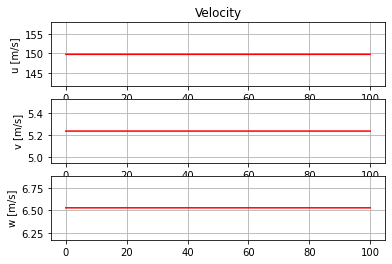

In [42]:
pltr.LinVel(frame = 'body')

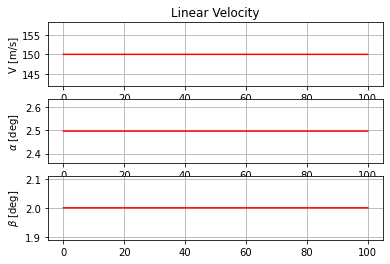

In [43]:
pltr.LinVel(frame = 'aero')

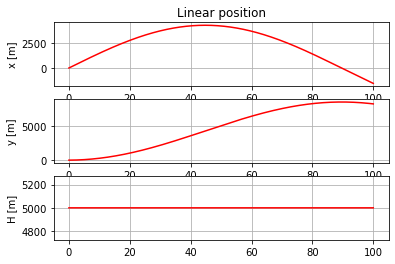

In [44]:
pltr.LinPos()

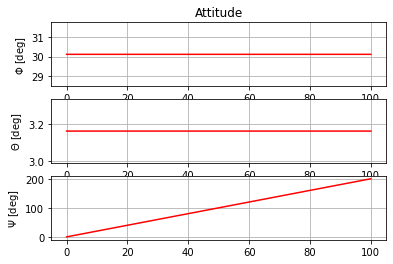

In [45]:
pltr.Attitude()

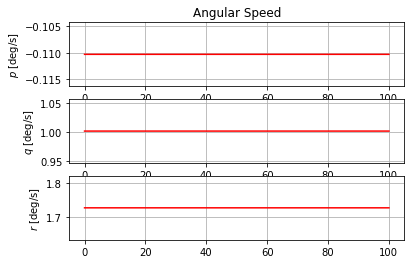

In [46]:
pltr.AngVel()

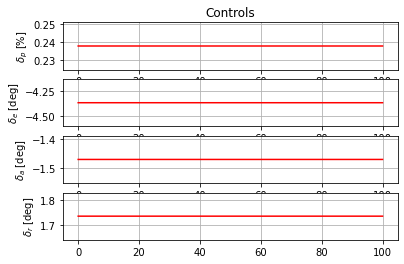

In [47]:
pltr.Controls()

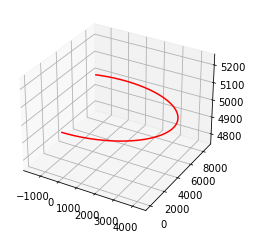

In [48]:
pltr.LinPos3D()

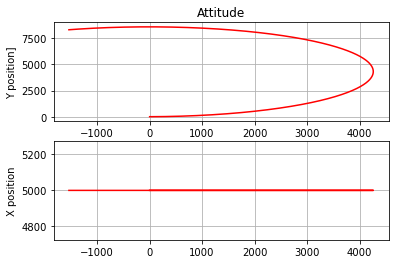

In [49]:
pltr.linPos2D()

## Simulating Pull-Up maneuver

Xe, Ue = System.trimmer(condition='pullUp', HE =5000., VE= 150, dTH = 10.)

In [53]:
solution, control = System.propagate(Xe, Ue, TF = 200)

In [54]:
pltr.states = solution
pltr.time = System.time
pltr.control = control

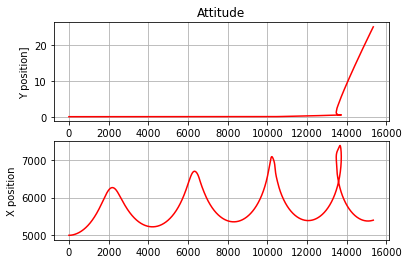

In [55]:
pltr.linPos2D()

## Simulation with disturbances on initial condition

We can easly add perturbations at initial conditions or equilibrium controls, as follows:

In [57]:
Xe, Ue = System.trimmer(condition='cruize', HE = 5000., VE = 150)

In [61]:
solution, control = System.propagate(Xe, Ue, TF = 400, perturbation = True, state = {'alpha': 5, 'beta':2})

In [62]:
pltr.states = solution
pltr.time = System.time
pltr.control = control

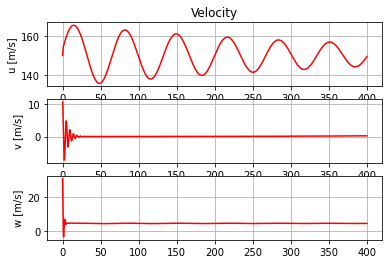

In [63]:
pltr.LinVel(frame = 'body')

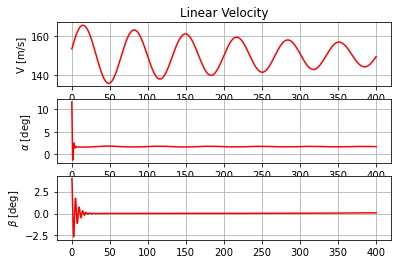

In [64]:
pltr.LinVel(frame = 'aero')

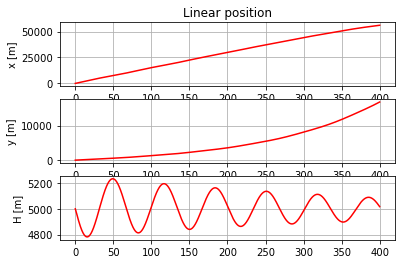

In [65]:
pltr.LinPos()

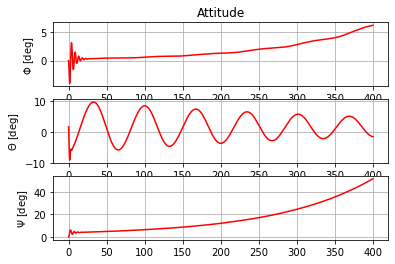

In [66]:
pltr.Attitude()

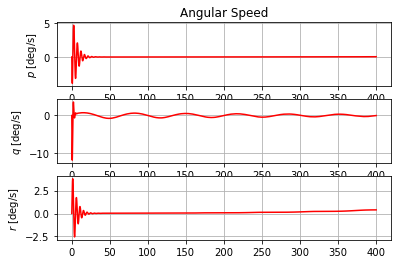

In [67]:
pltr.AngVel()

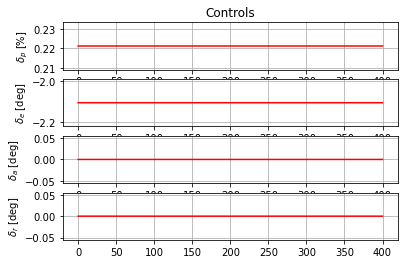

In [68]:
pltr.Controls()

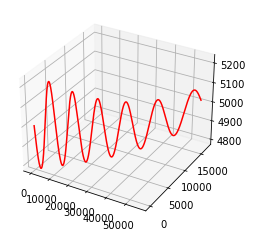

In [69]:
pltr.LinPos3D()

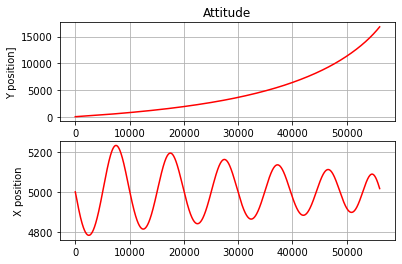

In [70]:
pltr.linPos2D()